# Data Exploration of different datasets

## Datasets used in this project

- [MARS dataset](https://www.sciencedirect.com/science/article/pii/S2352340923000604)
- [ITM-Rec dataset](https://arxiv.org/abs/2303.10230)

In [50]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

In [51]:
ITEM_COL: str = "item_id"
USER_COL: str = "user_id"
TIME_COL: str = "timestamp"
RATING_COL: str = "rating"
RELEVANT_COL: str = "relevant"
DATA_FOLDER: str = "../data"
TEST_SIZE: float = 0.4
VAL_SIZE: float = 0.2
RANDOM_STATE: int = 42
PADDING_VAL: int = 0
INIT_TOKEN: str = "<|init|>"
END_TOKEN: str = "<|end|>"
EMPTY_TOKEN: str = "<|empty|>"


@dataclass
class RawDataset:
    interactions: pd.DataFrame
    i_feats: pd.DataFrame
    u_feats: pd.DataFrame


def add_relevant_col(df: pd.DataFrame):
    if RELEVANT_COL not in df.columns:
        # An item is relevant if its rating is greater or equal than the threshold
        # The threshold is the mean of the ratings of the user
        mean_user_ratings = df.groupby(USER_COL)[RATING_COL].transform("mean")
        df[RELEVANT_COL] = df[RATING_COL] >= mean_user_ratings


def clean_df(df: pd.DataFrame):
    df.columns = (
        df.columns.str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )

## Datasets

In [52]:
def load_mars() -> RawDataset:
    """Load and preprocess the MARS dataset.

    This loader combines English and French rating files and merges them with
    item metadata. It also standardizes column names and ensures consistent
    schema across sources.

    Returns:
        pd.DataFrame: The MARS dataset.
    """
    items_en = pd.read_csv(f"{DATA_FOLDER}/raw/mars/items_en.csv")
    items_fr = pd.read_csv(f"{DATA_FOLDER}/raw/mars/items_fr.csv")
    users_en = pd.read_csv(f"{DATA_FOLDER}/raw/mars/users_en.csv")
    users_fr = pd.read_csv(f"{DATA_FOLDER}/raw/mars/users_fr.csv")
    ratings_en = pd.read_csv(f"{DATA_FOLDER}/raw/mars/explicit_ratings_en.csv")
    ratings_fr = pd.read_csv(f"{DATA_FOLDER}/raw/mars/explicit_ratings_fr.csv")

    df_interactions = pd.concat([ratings_en, ratings_fr], ignore_index=True)
    df_items = pd.concat([items_en, items_fr], ignore_index=True)
    df_users = pd.concat([users_en, users_fr], ignore_index=True)

    df_interactions.rename(
        columns={
            "user_id": USER_COL,
            "item_id": ITEM_COL,
            "rating": RATING_COL,
            "created_at": TIME_COL,
        },
        inplace=True,
    )

    df_items.rename(
        columns={"item_id": ITEM_COL, "type": "item_type"},
        inplace=True,
    )

    df_users.rename(columns={"user_id": USER_COL})

    clean_df(df_interactions)
    clean_df(df_items)
    clean_df(df_users)

    add_relevant_col(df_interactions)

    return RawDataset(interactions=df_interactions, i_feats=df_items, u_feats=df_users)


def load_itm() -> RawDataset:
    """Load and preprocess the ITM dataset.

    This loader merges ratings, items, and user information into a unified
    DataFrame and normalizes column names for consistency.

    Returns:
        pd.DataFrame: The ITM dataset.
    """
    ratings_df = pd.read_csv(f"{DATA_FOLDER}/raw/itm/ratings.csv")
    items_df = pd.read_csv(f"{DATA_FOLDER}/raw/itm/items.csv")
    users_df = pd.read_csv(f"{DATA_FOLDER}/raw/itm/users.csv")

    ratings_df.rename(
        columns={
            "UserID": USER_COL,
            "Item": ITEM_COL,
            "Rating": RATING_COL,
        },
        inplace=True,
    )
    items_df.rename(columns={"Item": ITEM_COL}, inplace=True)
    users_df.rename(columns={"UserID": USER_COL}, inplace=True)

    clean_df(ratings_df)
    clean_df(items_df)
    clean_df(users_df)

    add_relevant_col(ratings_df)

    return RawDataset(interactions=ratings_df, i_feats=items_df, u_feats=users_df)

## Exploration

In [53]:
def plot_interactions_per_user(interactions: pd.DataFrame):
    num_interactions_per_user = (
        interactions.groupby(USER_COL)
        .size()
        .sort_values(ascending=False)  # opcional: ordenados por actividad
    )

    plt.figure(figsize=(12, 5))
    plt.plot(num_interactions_per_user.values)  # type: ignore
    plt.title("Number of interactions per user")
    plt.xlabel("Users (sorted)")
    plt.ylabel("Number of interactions")
    plt.show()

MARS

In [54]:
raw_dataset = load_mars()
interactions = raw_dataset.interactions
items = raw_dataset.i_feats
users = raw_dataset.u_feats

print("Number of interactions:", len(interactions))
print("Number of items:", len(items))
print("Number of users:", len(users))
interactions.head()

Number of interactions: 88998
Number of items: 2618
Number of users: 131247


,user_id,item_id,watch_percentage,timestamp,rating,relevant
0,224557,510,100,2018-09-28 16:18:29,10,True
1,224557,615,100,2018-09-28 16:22:22,10,True
2,224557,7680,100,2018-09-28 16:23:34,10,True
3,224293,510,100,2018-09-28 17:20:30,10,True
4,224293,515,100,2018-09-28 17:40:02,10,True


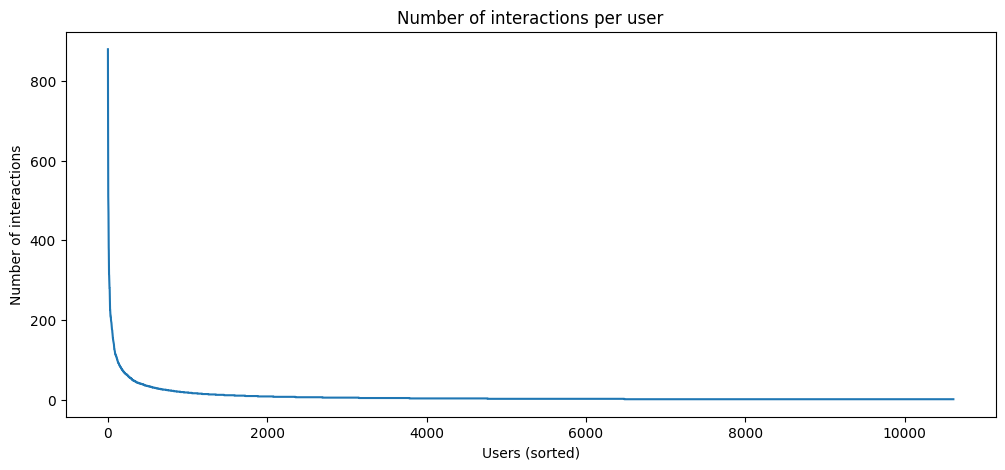

In [55]:
plot_interactions_per_user(interactions)

ITM

In [56]:
raw_dataset = load_itm()
interactions = raw_dataset.interactions
items = raw_dataset.i_feats
users = raw_dataset.u_feats

print("Number of interactions:", len(interactions))
print("Number of items:", len(items))
print("Number of users:", len(users))
interactions.head()

Number of interactions: 5230
Number of items: 70
Number of users: 476


,user_id,item_id,rating,app,data,ease,class,semester,lockdown,relevant
0,1173,28,5,4,4.0,4,DA,Fall,PRE,True
1,1173,41,5,4,4.0,4,DA,Fall,PRE,True
2,1173,61,4,4,4.0,4,DA,Fall,PRE,True
3,1173,22,1,1,2.0,2,DA,Fall,PRE,False
4,1173,27,1,1,2.0,2,DA,Fall,PRE,False


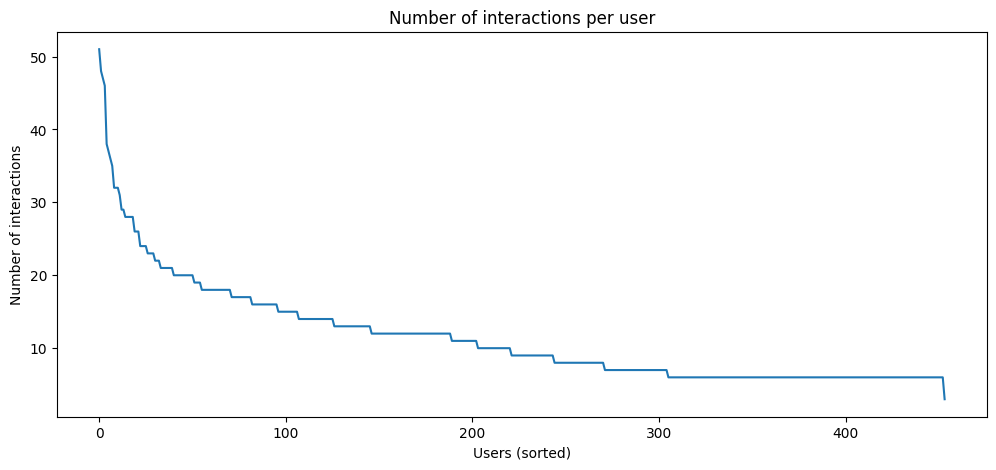

In [57]:
plot_interactions_per_user(interactions)